In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import shap

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score

from xgboost import XGBRegressor

ROOT = Path.cwd().parents[1]
print(ROOT)

DATA_RAW = ROOT/"data/raw"
DATA_PROCESSED = ROOT/"data/processed"

c:\Users\sebas\PycharmProjects\Git\BoxOffice_Oracle


In [2]:
model_df = pd.read_csv(
    DATA_RAW/"fe_groups/g3.csv"
)

print(model_df.shape)
model_df.head()

(2255, 55)


,Unnamed: 0.1,Unnamed: 0,tconst,primaryTitle,startYear,the_numbers_url,scrape_success,scrape_error,opening_weekend_gross,opening_theaters,...,actor_1_name,actor_2_name,actor_3_name,g3_distance_from_nearest_seasonal_peak,g3_nearest_seasonal_peak_category,g3_nearby_general_movies_20d_count,g3_nearby_similar_genre_movies_20d_count,g3_nearby_general_similar_budget_movies_20d_count,g3_nearby_similar_genre_similar_budget_movies_20d_count,g3_budget_x_distance_from_peak
0,0,1112,tt1311067,Halloween II,2009.0,https://www.the-numbers.com/movie/Halloween-II,True,NaN,7676836.0,1217.0,...,Scout Taylor-Compton,Tyler Mane,Malcolm McDowell,3,halloween,0,0,0.0,0.0,7500000.0
1,1,689,tt0816462,Conan the Barbarian,2011.0,https://www.the-numbers.com/movie/Conan-the-Ba...,True,NaN,9479373.0,1358.0,...,Jason Momoa,Ron Perlman,Rose McGowan,44,spring,0,0,0.0,0.0,880000000.0
2,2,1974,tt4731008,The Wild Life,2016.0,https://www.the-numbers.com/movie/Wild-Life-The,True,NaN,4001400.0,1140.0,...,Matthias Schweighöfer,Kaya Yanar,Ilka Bessin,28,halloween,0,0,NaN,NaN,NaN
3,3,980,tt1160419,Dune: Part One,2021.0,https://www.the-numbers.com/movie/Dune,True,NaN,6025091.0,915.0,...,Timothée Chalamet,Rebecca Ferguson,Zendaya,6,christmas,0,0,0.0,0.0,270000000.0
4,4,1291,tt1540128,Playing for Keeps,2012.0,https://www.the-numbers.com/movie/Playing-for-...,True,NaN,1406300.0,1148.0,...,Gerard Butler,Jessica Biel,Dennis Quaid,24,halloween,0,0,0.0,0.0,840000000.0


In [10]:
target = "log_opening_weekend_gross"

g2_features = [
    'g3_distance_from_nearest_seasonal_peak',
    'g3_nearby_general_movies_20d_count',
    'g3_nearby_similar_genre_movies_20d_count',
    'g3_nearby_general_similar_budget_movies_20d_count',
    'g3_nearby_similar_genre_similar_budget_movies_20d_count',
    'g3_budget_x_distance_from_peak'
]

numeric_features = [
    # "opening_theaters",
    "production_budget",
    "runtime_minutes",
    "release_month",
    "release_day_of_year",
] + g2_features

people_features = [
    "director_id",
    "writer_id",
    "actor_1",
    "actor_2",
    "actor_3",
]

categorical_features = [
    # "release_type",
    "distributor",
    "MPA_rating",
    "genre",
    "subgenre",
    "source",
    "production_method",
    "creative_type",
    "production_countries",
    "languages",
    'g3_nearest_seasonal_peak_category'
] + people_features

In [11]:
feature_cols = numeric_features + categorical_features

model_data = model_df[
    feature_cols + [target, "opening_weekend_gross"]
].copy()

X = model_data[feature_cols]
y = model_data[target]

print(X.shape)
print(y.shape)

(2255, 25)
(2255,)


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [13]:
y_test_dollars = np.expm1(y_test)

In [14]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [15]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    pred_log = model.predict(X_test)

    r2_log = r2_score(y_test, pred_log)
    mae_log = mean_absolute_error(y_test, pred_log)

    pred_dollars = np.expm1(pred_log)

    mae_dollars = mean_absolute_error(y_test_dollars, pred_dollars)

    results = {
        "model": name,
        "r2_log": r2_log,
        "mae_log": mae_log,
        "mae_dollars": mae_dollars
    }

    return results, pred_log, pred_dollars

In [16]:
ridge_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])

ridge_results, ridge_pred_log, ridge_pred_dollars = evaluate_model(
    "Ridge Baseline",
    ridge_model,
    X_train,
    X_test,
    y_train,
    y_test
)

ridge_results

{'model': 'Ridge Baseline',
 'r2_log': 0.6262112584124195,
 'mae_log': 0.8060754673454896,
 'mae_dollars': 15776329.939759618}

In [17]:
xgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42
    ))
])

xgb_results, xgb_pred_log, xgb_pred_dollars = evaluate_model(
    "XGBoost Baseline",
    xgb_model,
    X_train,
    X_test,
    y_train,
    y_test
)

xgb_results

{'model': 'XGBoost Baseline',
 'r2_log': 0.6590153200635276,
 'mae_log': 0.7441150696076317,
 'mae_dollars': 11648314.178288694}

In [18]:
results_df = pd.DataFrame([
    ridge_results,
    xgb_results
])

results_df

,model,r2_log,mae_log,mae_dollars
0,Ridge Baseline,0.626211,0.806075,1.577633e+07
1,XGBoost Baseline,0.659015,0.744115,1.164831e+07


In [19]:
plot_df = pd.DataFrame({
    "actual": y_test_dollars,
    "predicted": xgb_pred_dollars
})

fig = px.scatter(
    plot_df,
    x="actual",
    y="predicted",
    title="XGBoost Baseline: Actual vs Predicted",
    opacity=0.6
)

fig.add_shape(
    type="line",
    x0=plot_df["actual"].min(),
    y0=plot_df["actual"].min(),
    x1=plot_df["actual"].max(),
    y1=plot_df["actual"].max(),
)

fig.show()

In [20]:
X_train_transformed = (
    xgb_model.named_steps["preprocessor"]
    .transform(X_train)
)

X_test_transformed = (
    xgb_model.named_steps["preprocessor"]
    .transform(X_test)
)

feature_names = (
    xgb_model.named_steps["preprocessor"]
    .get_feature_names_out()
)

trained_xgb = xgb_model.named_steps["model"]

In [21]:
explainer = shap.TreeExplainer(trained_xgb)

X_shap = X_test_transformed[:500]

shap_values = explainer.shap_values(X_shap)

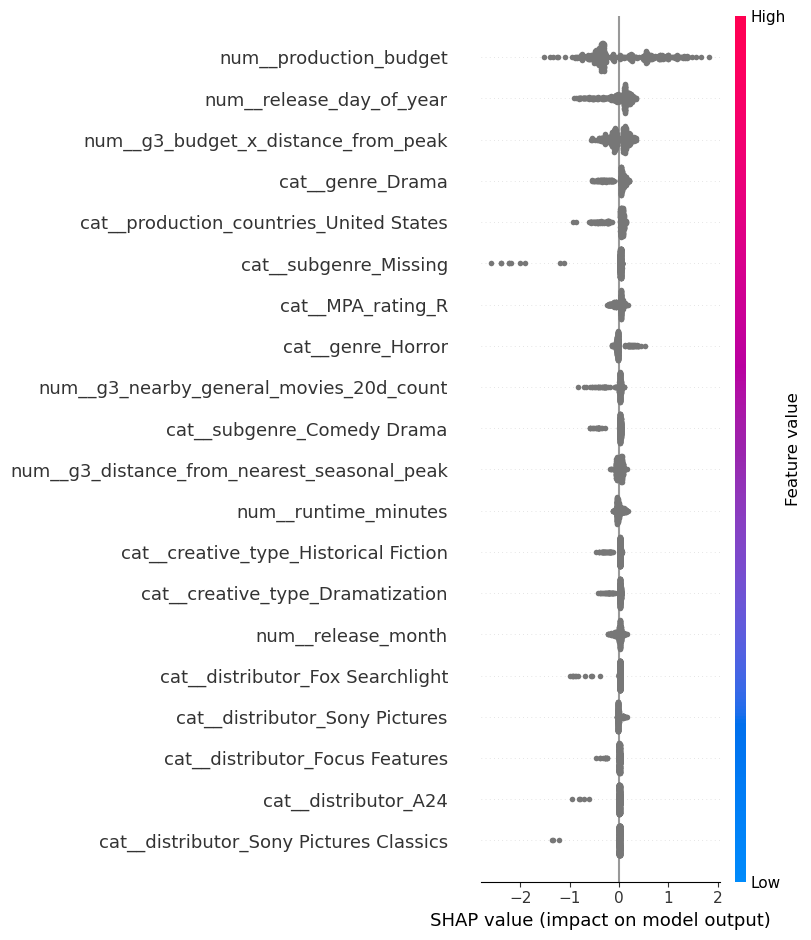

In [22]:
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names
)

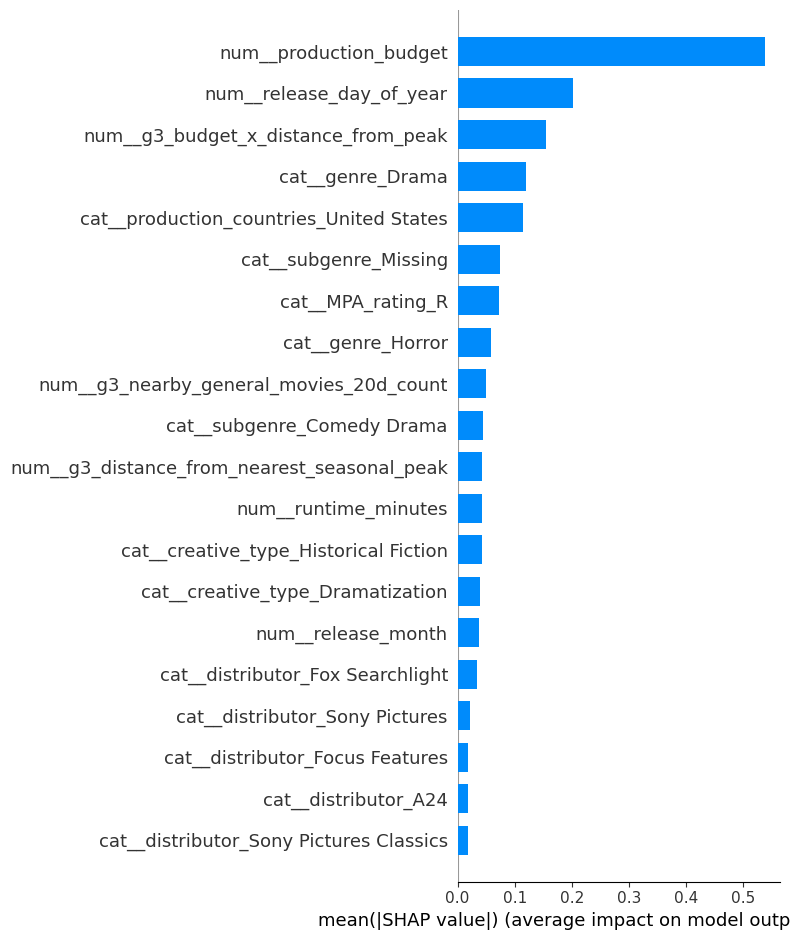

In [23]:
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names,
    plot_type="bar"
)

In [24]:
error_df = X_test.copy()

error_df["actual_log"] = y_test
error_df["pred_log"] = xgb_pred_log

error_df["actual_opening_weekend"] = np.expm1(y_test)
error_df["pred_opening_weekend"] = xgb_pred_dollars

error_df["abs_error"] = (
    error_df["actual_opening_weekend"] -
    error_df["pred_opening_weekend"]
).abs()

error_df.sort_values("abs_error", ascending=False).head(20)

,production_budget,runtime_minutes,release_month,release_day_of_year,g3_distance_from_nearest_seasonal_peak,g3_nearby_general_movies_20d_count,g3_nearby_similar_genre_movies_20d_count,g3_nearby_general_similar_budget_movies_20d_count,g3_nearby_similar_genre_similar_budget_movies_20d_count,g3_budget_x_distance_from_peak,...,director_id,writer_id,actor_1,actor_2,actor_3,actual_log,pred_log,actual_opening_weekend,pred_opening_weekend,abs_error
1847,400000000.0,181.0,4,116,26,11,0,0.0,0.0,1.040000e+10,...,nm0751577,nm1321655,nm0000375,nm0262635,nm0749263,19.693568,18.798754,3.571150e+08,145946944.0,2.111681e+08
1718,200000000.0,120.0,2,47,43,7,1,0.0,0.0,8.600000e+09,...,nm3363032,nm3363032,nm1569276,nm0430107,nm2143282,19.123798,18.171446,2.020040e+08,77939688.0,1.240643e+08
2126,145000000.0,114.0,7,202,17,8,2,2.0,1.0,2.465000e+09,...,nm1950086,nm1950086,nm3053338,nm0331516,nm4793987,18.903243,17.584742,1.620220e+08,43346720.0,1.186753e+08
1619,160000000.0,123.0,3,76,14,9,1,5.0,1.0,2.240000e+09,...,nm0174374,nm0154716,nm0914612,nm1405398,nm1812656,18.978870,17.886982,1.747506e+08,58643188.0,1.161074e+08
1620,160000000.0,123.0,3,76,14,9,1,5.0,1.0,2.240000e+09,...,NaN,NaN,nm5177626,nm11380870,nm3592451,18.978870,17.886982,1.747506e+08,58643188.0,1.161074e+08
2204,200000000.0,100.0,6,166,19,7,1,0.0,0.0,3.800000e+09,...,nm1626375,nm0498834,nm0688132,nm1638321,nm10143485,18.853772,17.886089,1.542017e+08,58590864.0,9.561081e+07
1423,74000000.0,91.0,7,191,6,15,2,3.0,1.0,4.440000e+08,...,nm0049633,nm3821363,nm0136797,nm1853544,nm0000273,18.566670,17.187111,1.157184e+08,29125100.0,8.659331e+07
1422,74000000.0,91.0,7,191,6,15,2,3.0,1.0,4.440000e+08,...,nm0049633,nm0528244,nm0000113,nm0358316,nm0000474,18.566670,17.187111,1.157184e+08,29125100.0,8.659331e+07
203,115000000.0,139.0,5,139,46,11,2,3.0,0.0,5.290000e+09,...,nm0000184,nm0000184,nm0159789,nm0000204,nm0000191,18.501669,17.552853,1.084358e+08,41986244.0,6.644960e+07
1864,200000000.0,89.0,6,172,13,8,2,1.0,0.0,2.600000e+09,...,nm2155757,nm0005124,nm0000158,nm0000741,nm0001633,18.610541,17.816757,1.209081e+08,54666256.0,6.624181e+07


In [25]:
results_df.to_csv(
    DATA_PROCESSED/"feature_testing/g3_model_results.csv",
    index=False
)

error_df.to_csv(
    DATA_PROCESSED/"feature_testing/g3_xgb_test_errors.csv",
    index=False
)